# Prabal Ghosh

# Date- 23/06/2025

<center><img width=60% src="http://www.i3s.unice.fr/~lingrand/efeliaUnica.png"><br/><br/>
<font size=+3><b>Introduction to Pytorch library and neural networks</b></font><br/><br/>
<font size=+1>Diane Lingrand (diane.lingrand@univ-cotedazur)<br/>
Deep Learning School<br/>
    2025 - June/July<br/></font>
    <img width=14% src="http://www.i3s.unice.fr/~lingrand/cc-long.png">
    </center>

In [1]:
#necessary imports
import numpy as np
import random

import torch
torch.__version__
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob

In [2]:
# making the code device agnostic
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
device

device(type='cpu')

# Introduction to pytorch tensors and operations

## Variables of different types and shapes

### scalar values
Let's create a simple integer of value 2.

In [3]:
a = torch.tensor(2)

In [4]:
a

tensor(2)

In [5]:
print('nb dim = ', a.dim(), '\n shape = ',a.shape, '\n dtype = ', a.dtype, '\n value = ', a.item())

nb dim =  0 
 shape =  torch.Size([]) 
 dtype =  torch.int64 
 value =  2


🤔 <b><font color='purple'>Question:</font></b> Construct also a single float.

In [6]:
# your work
b = torch.tensor(2.0, dtype=float)
b

tensor(2., dtype=torch.float64)

In [7]:
print('nb dim = ', b.dim(), '\n shape = ',b.shape, '\n dtype = ', b.dtype, '\n value = ', b.item())

nb dim =  0 
 shape =  torch.Size([]) 
 dtype =  torch.float64 
 value =  2.0


In [8]:
# hint
# same constructor as for the integer but using a float value
b = torch.tensor(2.0)
b

tensor(2.)

### vectors
Let's now create a simple vector of 3 floats!

In [9]:
# your work
b = torch.tensor([1.0,2.0,3.0])
b

tensor([1., 2., 3.])

In [10]:
# hint
# same constructor as for the previous question but using an array

In [11]:
print('nb dim = ', b.dim(), '\n shape = ',b.shape, '\n dtype = ', b.dtype)

nb dim =  1 
 shape =  torch.Size([3]) 
 dtype =  torch.float32


🤔 <b><font color='purple'>Question:</font></b> Construct also a vector of 4 integers.

In [12]:
# your work
b_bis = torch.tensor([1,2,3,4])
b_bis

tensor([1, 2, 3, 4])

In [13]:
print('nb dim = ', b_bis.dim(), '\n shape = ',b_bis.shape, '\n dtype = ', b_bis.dtype)

nb dim =  1 
 shape =  torch.Size([4]) 
 dtype =  torch.int64


### matrix or 2d-array
A small 2d array of integers:

In [14]:
c = torch.tensor([[2, 7, 3],[1,4,9]])

In [15]:
c

tensor([[2, 7, 3],
        [1, 4, 9]])

In [16]:
print('nb dim = ', c.dim(), '\n shape = ',c.shape, '\n dtype = ', c.dtype)

nb dim =  2 
 shape =  torch.Size([2, 3]) 
 dtype =  torch.int64


🤔 <b><font color='purple'>Question:</font></b> Build a small grey levels picture

In [17]:
# your work
d = torch.tensor([[1,2,3],[4,5,6],[7,8,9], [10,11,12]])
d

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

In [18]:
print('nb dim = ', d.dim(), '\n shape = ',d.shape, '\n dtype = ', d.dtype)

nb dim =  2 
 shape =  torch.Size([4, 3]) 
 dtype =  torch.int64


In [19]:
# hint 1
# a grey level picture is a 2d array of integer values between 0 and 255 or float values between 0 and 1.

In [20]:
# hint 2
# any 2d array can be displayed using plt.imshow
# in case of no color channels, the default colormap is using false colors. In order to display a grey scale image, the grey colormap should be selected:
# plt.imshow(myImage, cmap='gray')

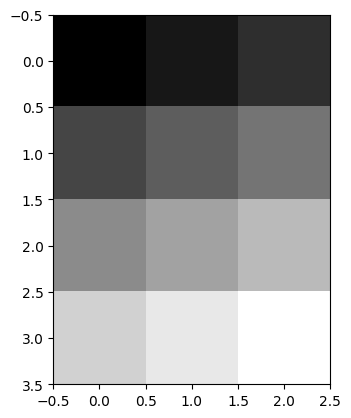

In [21]:
import matplotlib.pyplot as plt
plt.imshow(d, cmap='gray')

### tensor or nd-array ($n>2$)
A 3d array:

In [22]:
d = torch.tensor([[[2, 7, 3, 6],
                   [1, 4, 9, 11]],
                  [[5, 4, 0, 6],
                   [10, 8, 1, 3]],
                  [[3, 6, 2, 8],
                   [9, 1, 2, 7]]])
print(d)

tensor([[[ 2,  7,  3,  6],
         [ 1,  4,  9, 11]],

        [[ 5,  4,  0,  6],
         [10,  8,  1,  3]],

        [[ 3,  6,  2,  8],
         [ 9,  1,  2,  7]]])


In [23]:
print('nb dim = ', d.dim(), '\n shape = ',d.shape, '\n dtype = ', d.dtype)

nb dim =  3 
 shape =  torch.Size([3, 2, 4]) 
 dtype =  torch.int64


In [24]:
# plt.imshow(d)

🤔 <b><font color='purple'>Question:</font></b> Build a small colored picture

In [25]:
# your work


nb dim =  3 
 shape =  torch.Size([3, 2, 3]) 
 dtype =  torch.int64


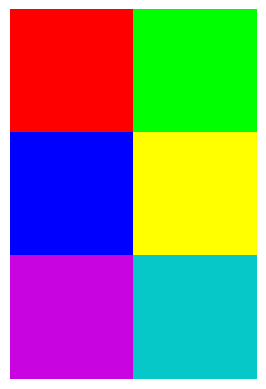

In [26]:
# hint
# the last dimension of the tensor correspond to color channels. A basic color image can be expressed using (Red,Green,Blue) components

# A small colored picture (height=2, width=2, channels=3 for RGB)
colored_image = torch.tensor([[[255, 0, 0], [0, 255, 0]],
                              [[0, 0, 255], [255, 255, 0]],
                              [[200,5,225],[7,200,200]]])

print('nb dim = ', colored_image.dim(), '\n shape = ',colored_image.shape, '\n dtype = ', colored_image.dtype)

plt.imshow(colored_image)
plt.axis('off')
plt.show()

## Variables: device

In [27]:
# default device
print("d is stored on device: ", d.device)

d is stored on device:  cpu


In [28]:
# move the tensor d to the device
d_gpu = d.to(device)

In [29]:
print("d_gpu is stored on device: ", d_gpu.device)

d_gpu is stored on device:  cpu


🤔 <b><font color='purple'>Question:</font></b> Check if you have or not a GPU on your computer. You can also try, on google colab, to change the runtime to GPU or not GPU.

In [30]:
# one solution
# run the previous cells

## Variables: creation

Documentation available on <a href="https://pytorch.org/docs/stable/torch.html#tensor-creation-ops">pytorch site</a>. Experiments other functions than these:

In [31]:
c

tensor([[2, 7, 3],
        [1, 4, 9]])

In [32]:
# zeros
z0 = torch.zeros(2,3)
print(z0)
zc = torch.zeros_like(c) # c was defined previously at the beginning of this section
print(zc)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[0, 0, 0],
        [0, 0, 0]])


In [33]:
# ones
z1 = torch.ones(3,4)
print(z1)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [34]:
# linear
zl = torch.linspace(0,1,5)
print(zl)

tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [35]:
# random
zr = torch.randint(0,10,(3,10))
print(zr)

tensor([[1, 9, 4, 6, 8, 4, 7, 6, 8, 6],
        [5, 7, 5, 2, 3, 2, 8, 6, 8, 6],
        [4, 7, 4, 5, 1, 9, 2, 3, 2, 3]])


In [36]:
# from and to numpy array
anArray = np.array([1,5,2,7])
aTensor = torch.from_numpy(anArray)
backToNumpy = aTensor.numpy()
print(anArray,aTensor,backToNumpy, sep='\n')

[1 5 2 7]
tensor([1, 5, 2, 7])
[1 5 2 7]


🤔 <b><font color='purple'>Question:</font></b> Create 2 color images of dimension (20x20): one with random pixels and the other one with color gradients.

In [37]:
# your work


In [38]:
# hint 1
# use torch.randint function

In [39]:
# your work

In [ ]:
# hint2 for gradient
# use linspace for linear 1d gradient (let's call it red1dgradient)
red1dgradient = torch.linspace(0, 1, 20)
print(red1dgradient)
# augment the dimensions using unsqueeze

# multiply transpose(red1dgradient) by red1dgradient in order to get a 2d gradient
# do the same on another channel using another direction
# stack the channels (green could be full black) using torch.dstack

tensor([0.0000, 0.0526, 0.1053, 0.1579, 0.2105, 0.2632, 0.3158, 0.3684, 0.4211,
        0.4737, 0.5263, 0.5789, 0.6316, 0.6842, 0.7368, 0.7895, 0.8421, 0.8947,
        0.9474, 1.0000])


tensor([[[ 76,  29,  70],
         [ 79, 177, 171],
         [209, 203, 163],
         ...,
         [113, 154, 116],
         [183,  81, 159],
         [110, 123,  74]],

        [[ 18,  86,  42],
         [199, 135, 190],
         [113, 117, 226],
         ...,
         [ 14,  78,  71],
         [161,  99,  51],
         [196, 182, 225]],

        [[134, 208,  63],
         [ 42,  25,  47],
         [ 63, 225, 127],
         ...,
         [130, 213, 142],
         [200,  46,  72],
         [ 85, 135, 125]],

        ...,

        [[230,  71,  17],
         [141,  33,   0],
         [ 42, 176, 159],
         ...,
         [144, 109, 118],
         [114,  70, 149],
         [238, 199, 175]],

        [[181, 162, 153],
         [ 28, 211,  44],
         [ 25,  69, 148],
         ...,
         [167, 197,  77],
         [ 39,  66, 118],
         [100, 123, 172]],

        [[ 52, 194,  47],
         [223,  59,  88],
         [181, 191, 112],
         ...,
         [  2, 118, 127],
        

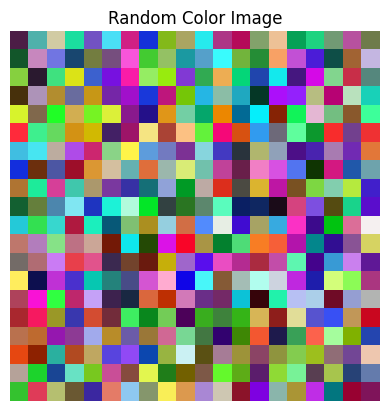

In [43]:
# your work

# Create a 20x20 color image with random pixels (RGB, values between 0 and 255)
random_image = torch.randint(0, 256, (20, 20, 3), dtype=torch.uint8)
print(random_image)
print('nb dim = ', random_image.dim(), '\n shape = ',random_image.shape, '\n dtype = ', random_image.dtype)

# Display the random image
plt.imshow(random_image)
plt.title('Random Color Image')
plt.axis('off') # Hide axes
plt.show()

## Operations on tensors

Documentation on math operations on the <a href="https://pytorch.org/docs/stable/torch.html#math-operations">pytorch site</a>.

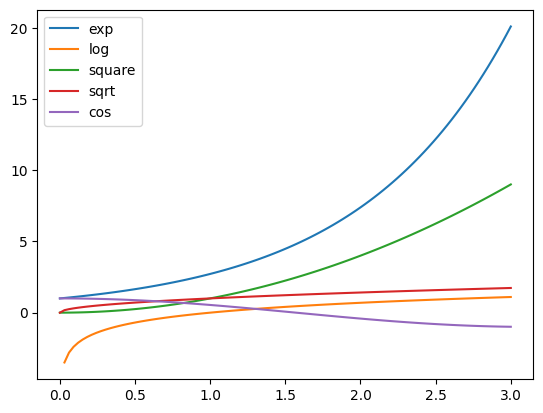

In [44]:
x = torch.linspace(0,3,100)

plt.plot(x,torch.exp(x), label='exp')
plt.plot(x,torch.log(x), label='log')
plt.plot(x,x*x, label='square')
plt.plot(x,torch.sqrt(x), label='sqrt')
plt.plot(x,torch.cos(x), label='cos')
plt.legend()


# Autograd

Automatic differentiation in pytorch. Before dealing with gradient descent and gradients for neural networks, let's play with a very simple example:

In [45]:
# a simple function from R2 to R that you can modify
def f(a,b):
    return 3*a + a*b

🤔 <b><font color='purple'>Question:</font></b> Set 2 scalars with values 10.0 and 20.0 with that requires the gradient computation. Compute to value of the function <code>f</code> and it's gradient vector.

In [47]:
# hint 1
# setting m and n
m = torch.tensor(10.0, requires_grad=True)
n = torch.tensor(20.0, requires_grad=True)

In [48]:
# hint 2
# forward the computation
output = f(m,n)

In [49]:
# hint 3
# backward for the gradients
output.backward()

In [50]:
# hint 4
# access to the gradient values before releasing the tree
gradm = m.grad
gradn = n.grad

In [51]:
print(f"Gradient of m: {gradm.item()}")
print(f"Gradient of n: {gradn.item()}")

Gradient of m: 23.0
Gradient of n: 10.0


🤔 Question: Play with more complex <code>f</code> functions.

In [52]:
# your work

def complex_function(x, y):
    return torch.sin(x) * torch.cos(y) + x**2 - y**2

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
output = complex_function(x, y)
output.backward()
grad_x = x.grad
grad_y = y.grad
print(f"Gradient with respect to x: {grad_x.item()}")
print(f"Gradient with respect to y: {grad_y.item()}")

Gradient with respect to x: 1.7751548290252686
Gradient with respect to y: -4.7651472091674805


# Simple neural networks for classification of handwritten digits

Following what you have seen in the slides, we will perform the classification of the MNIST handwritten digits using the simplest neural network. We thus add more elements to this simplest network in order to improve the classification.

## Loading the MNIST dataset

In [53]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:09<00:00, 1098297.70it/s]


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 167800.51it/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 1698583.91it/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1441801.92it/s]


Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw



<code>train_data</code> and <code>test_data</code> are <code>Dataset</code> pytorch objects. You can plot some informations:

In [54]:
print(train_data, test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor() Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


Theses `Dataset` objects are build from data arrays accessible through the `data` field and targets using the `targets` field:

In [55]:
print('train:',train_data.data.shape, train_data.targets.shape, train_data.data.dtype,\
      '\n test:',test_data.data.shape, test_data.targets.shape, test_data.data.dtype)

train: torch.Size([60000, 28, 28]) torch.Size([60000]) torch.uint8 
 test: torch.Size([10000, 28, 28]) torch.Size([10000]) torch.uint8


The type of pixels is `torch.uint8` and we can verify that values are integers between 0 and 255.

In [56]:
print(train_data.data.min(),train_data.data.max())

tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


It is **important** to note that the `Dataset` object is responsible of transforming the data using specific tranformations. In our simple case, the only transformation is [toTensor](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html). This tranformation will scale the images build using `uint8` values between 0 and 255 into images of `float32` values between 0 and 1.

Let's observe the test data of index 0:

In [57]:
print(f'Original data of class {test_data[0][1]}')
for i in range(28):
    for j in range(28):
        print(f'{test_data.data[0][i,j]:3d}',end=' ')
    print('\n')


print('\n\n')

print('Transformed data: ')


for i in range(28):
    for j in range(28):
        print(f'{test_data[0][0][0,i,j]:0.1f}',end=' ')
    print('\n')



Original data of class 7
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198

Let's plot some data, randomly:

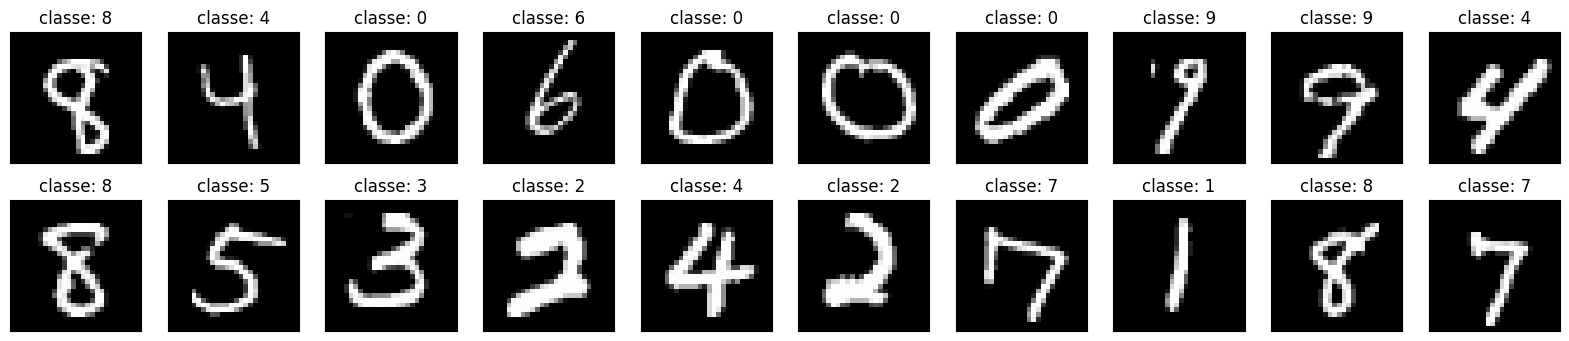

In [58]:
lenTrain = train_data.data.shape[0]
fig = plt.figure(figsize=(20, 4))
for i in range(1,21):
    index = random.randint(0,lenTrain-1)
    ax = fig.add_subplot(2, 10, i)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.imshow(train_data.data[index], cmap='gray')
    plt.title('classe: '+str(train_data.targets[index].item()))

In the purpose of learning a model, we need to:
- split the train dataset into train and validation sets
- build `Dataloader`s for both the train and the validation sets .

In [59]:
from torch.utils.data import random_split
train_data, val_data = random_split(train_data, [50000, 10000])
print("new train length: ", len(train_data.indices))
print("val length: ", len(val_data.indices))

new train length:  50000
val length:  10000


In [60]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(val_data, batch_size, shuffle = False)
test_loader = DataLoader(test_data, batch_size, shuffle = False)

## Building a model

Let's build the smallest and simplest model for MNIST classification.

In [61]:
class MyFirstModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # only the output layer
        self.linear = torch.nn.Linear(784,10)

    def forward(self, batch):
        # the forward will be apply to a batch of 2d images.
        # for the linear layer, we need to flatten the 28x28 images into a 1d 784 array
        # -1 is there to compute the remaining dimension which is also the batch size
        # or batch.shape[0]
        batch = batch.reshape(-1, 784)
        output = self.linear(batch)
        return(output)


In [62]:
print(test_data.data[0])

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

🤔 <b><font color='purple'>Question:</font></b> Create a instance of this class. Weights can be access using `weight` and `bias` instance variables of the linear layer. Print their shape and some values.

In [63]:
# your work

In [64]:
# hint for instantiation
model = MyFirstModel()

In [66]:
# hint for parameters
# what is model.linear.weight ? model.linear.bias?
model.linear.weight.shape, model.linear.bias.shape

(torch.Size([10, 784]), torch.Size([10]))

🤔 <b><font color='purple'>Question:</font></b> Are there variables that we can derive function with respect to them?

In [ ]:
# your work

In [ ]:
# answer
# look at the output of the previous function:
#    by default, bias and weights have `requires_grad` set to `True`
#    so they will be updated during the training process

## Setting the loss function

A classic loss function for multi classes classification is the [cross-entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html):

$ CE = -\displaystyle\sum_{i=0}^9 y_i \log{(\hat{y}_i)} $

where the estimated class probability is obtained by a `softmax` on the `logit`.

In [ ]:
myLoss = F.cross_entropy
myOptim = torch.optim.RMSprop(model.parameters(),lr=0.001, alpha=0.9)


🤔 <b><font color='purple'>Question:</font></b> What is the value of the loss function using the training data and the initial network?

In [ ]:
# your work

In [ ]:
# hint1
# you need to loop over train_loader batches

In [ ]:
# hint 2
# compute the loss using myLoss function on each batch of data
# for each batch, you need to feed forward the batch of data through the model
# sum all partial loss values

🤔 <b><font color='purple'>Question:</font></b> Same question for the accuracy (you can use the `accuracy_score` function from scikit-learn. Is it a good value?

In [ ]:
# your work

In [ ]:
# hint
# if you compute the accuracy per batch, you simply need to sum these values and divide by the number of batches

🤔 <b><font color='purple'>Question:</font></b> Compute now the accuracy on the test set. Compare to the accuracy of a random classifier.

In [ ]:
# your work

## Setting the optimizer

Many optimizers are proposed in the litterature. `RMSprop` or `Adam` are good starting ones.

In [ ]:
myOptim = torch.optim.RMSprop(model.parameters())

## Learning few epochs

Let's learn only 5 epochs:

In [ ]:
nbEpochs = 5

In [ ]:
# don't forget to send the model to the device (gpu ...)
model.to(device)

MyFirstModel(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

In [ ]:
# learning loop
epoch = 0
train_loss = 0

while epoch < nbEpochs:
    train_loss = 0
    train_acc = 0
    for batch, (X, y) in tqdm(enumerate(train_loader)):
        model.train() # set train mode
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        loss = myLoss(logits, y)
        train_loss += loss.item()
        with torch.inference_mode():
            pred1 = torch.argmax(logits,dim=1).to('cpu')
            train_acc += accuracy_score(pred1,y.to('cpu'))
        myOptim.zero_grad()
        loss.backward()
        myOptim.step()

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_loader)
    train_acc *= 100/len(train_loader)
    print(f"Train loss: {train_loss:.3f} | Train accuracy: {train_acc:.3f}%")
    # metrics for each epoch
    model.eval() # set to evaluation mode
    with torch.inference_mode():
        valid_loss = 0
        valid_acc = 0
        for b, (X,y) in tqdm(enumerate(val_loader)):
            X = X.to(device)
            valid_logits = model(X).to('cpu')
            valid_loss += myLoss(valid_logits, y)
            valid_acc += accuracy_score(torch.argmax(valid_logits,dim=1),y)
        valid_loss /= len(val_loader)
        valid_acc /= len(val_loader)

    print(f"Epoch {epoch} | Loss: {loss:.3f} | Valid loss: {valid_loss:.3f} | Valid acc: {100*valid_acc:.3f}%")
    epoch += 1

## Evaluation of a classification

Many metrics exist. The most frequently used are: accuracy, recall, precision, f1. They are all derived from the confusion matrix.

In [ ]:
test_size = len(test_data.targets)
pred_test = torch.empty(test_size)
with torch.inference_mode():
        for b, (X,y) in tqdm(enumerate(test_loader)):
            X = X.to(device)
            pred_test[b*batch_size:min((b+1)*batch_size,test_size)] = torch.argmax(model(X),dim=1).to('cpu')

In [ ]:
y_test = test_data.targets
cm = confusion_matrix(y_test, pred_test)
theLabels = [str(i) for i in range(10)]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=theLabels)
disp.plot()
disp.ax_.set_title('Confusion matrix (test dataset)')
plt.savefig('cmMNISTsimplest.pdf')

In [ ]:
print("accuracy score:  %.3f%%" %(accuracy_score(y_test,pred_test)*100))
print("recall score: ", (recall_score(y_test, pred_test, average='macro')*100))
print("F1 score: ", (f1_score(y_test, pred_test, average='macro')*100))

## Improving the neural net

### A more complex architecture

Add one or more layers to the previous architecture. Be careful that stacking linear layers is equivalent to a single linear layer. It is necessary to break the linearity using activation functions.

In [ ]:
# your work

In [ ]:
# hint1
# add for example 256 neurons between the input of dim 784 and the output of 10 neurons.
# in the constructor, you'll need to modify the existing linear layer and add another one
# don't forget to update the forward method also

In [ ]:
# hint2
# in the forward method, don't forget to add an activation between the 2 linear layers (e.g. ReLU).

In [ ]:
myOptim = torch.optim.RMSprop(model.parameters())

Let's print this new architecture:

In [ ]:
print(model)

We propose two other ways of visualisation:
- using torchviz.make_dot
- using tensorboard

### Visualisation using `torchviz.make_dot`

In [ ]:
# if needed
!pip install torchviz

In [ ]:
from torchviz import make_dot

In [ ]:
y = model(torch.empty(size=(10,3,380,380))
make_dot(y, params=dict(model.named_parameters()))

### Visualisation using `tensorboard`

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("torchlogs/")
writer.add_graph(model, torch.empty(size=(10,3,380,380)))
writer.close()

# You then need to open a console, navigate to the mentionned directory and launch:
# tensorboard --logdir=./torchlogs/
# At last, open the proposed link in your web browser (something like http://localhost:6006/)

### Improving the learning

Learning only 10 epochs is probably not the best solution. Loop for more epochs and stop when some metric on the valid set (loss, accuracy, ...) is not improving anymore.

In [ ]:
# your work

# Classification of texts using a simple text representation: BoW

The dataset we will use is extracted from the well-known 20 newsgroups dataset. We load only 4 classes with a potential confusion between 2 of them (about religion and atheism). We also remove informations we do not want the classifier to use (headers, footers and quotes):

In [ ]:
from sklearn.datasets import fetch_20newsgroups
my_categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'rec.motorcycles']
b_train = fetch_20newsgroups(subset='train', categories = my_categories, remove=('headers', 'quotes'))
b_test = fetch_20newsgroups(subset='test', categories = my_categories, remove=('headers', 'quotes'))

The purpose of this part of the lab is to learn and test a classification of those texts using a simple texts representation called 'Bag of Words'. Thus, the tokenizer will be very basic and will split texts into words.

Let's compute the vocabulary:

In [ ]:
import re
the_unique_tokens = np.array([])
for i,text in tqdm(enumerate(b_train.data)):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    tokens = np.array(text.split())
    utokens = np.unique(tokens)

    if len(tokens)!=0:
        the_unique_tokens = np.concatenate((the_unique_tokens,utokens),axis=None)

vocabulary = np.unique(the_unique_tokens)
print(vocabulary.shape)

2261it [00:49, 45.72it/s] 


(25312,)


🤔 <b><font color='purple'>Question:</font></b> Build a `dict` that convert tokens to a integer (the index of the token in the previous list of unique tokens). Name this dictionnary `str2int`.

In [ ]:
# your work

🤔 <b><font color='purple'>Question:</font></b> Similarly, build a `dict` that convert an integer to a string (inverse operation). Name this dictionnary `int2str`.

In [ ]:
# your work

🤔 <b><font color='purple'>Question:</font></b> Encode the string "What a good day!" using the `str2int` dict.

In [ ]:
# your work

🤔 <b><font color='purple'>Question:</font></b> Similar question: encode the string "What a good day Corentin!" using the `str2int` dict. Why is it not as easy as the previous question?

In [ ]:
# your work

🤔 <b><font color='purple'>Question:</font></b> Add a entry to the dictionaries corresponding to unknown tokens: `[UNK]`. Then, encode again the string "What a good day Corentin!" using the `str2int` dict.

In [ ]:
# your work

🤔 <b><font color='purple'>Question:</font></b> Compute the bag of words for train texts.

In [ ]:
# your work
bowTrain = np.zeros((len(b_train.target),len(str2int)))

🤔 <b><font color='purple'>Question:</font></b> Compute the bag of words for test texts.

In [ ]:
# your work

We split the train into train and validation sets:

In [ ]:
y_train = b_train.target
y_test = b_test.target
bowTrain, bowVal, y_train, y_val = train_test_split(bowTrain, y_train, test_size=0.20, random_state=42)

In [ ]:
# Building pytorch Datasets
dsTrain = torch.utils.data.TensorDataset(torch.tensor(bowTrain).to(torch.float32), torch.tensor(y_train))
dsValid = torch.utils.data.TensorDataset(torch.tensor(bowVal).to(torch.float32), torch.tensor(y_val))
dsTest = torch.utils.data.TensorDataset(torch.tensor(bowTest).to(torch.float32), torch.tensor(y_test))

In [ ]:
print(bowTrain.shape)

(1808, 25314)


In [ ]:
# Building pytorch Dataloaders
_batch_size = 32
train_loader = torch.utils.data.DataLoader(dsTrain, batch_size=_batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dsValid, batch_size=_batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dsTest, batch_size=_batch_size, shuffle=False)

🤔 <b><font color='purple'>Question:</font></b> With the inspiration from the MNIST classification, build, learn and evaluate a MLP model in the purpose of newsgroups classification (4 classes).

In [ ]:
# your work

dtype('float64')

🤔 <b><font color='purple'>Question:</font></b> If you still have time: classify the 20 classes!

In [ ]:
# your work

In [10]:
b = torch.tensor(2.0)

In [37]:
# your work
d = torch.tensor([[1,2,3],[4,5,6],[7,8,9], [10,11,12]])

In [38]:
print('nb dim = ', d.dim(), '\n shape = ',d.shape, '\n dtype = ', d.dtype)

nb dim =  2 
 shape =  torch.Size([4, 3]) 
 dtype =  torch.int64


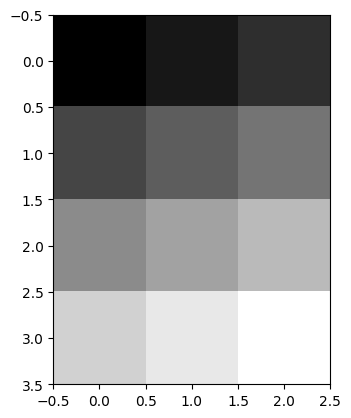

In [39]:
import matplotlib.pyplot as plt
plt.imshow(d, cmap='gray')

In [ ]:
# your work
# A small colored picture (height=2, width=2, channels=3 for RGB)
colored_image = torch.tensor([[[255, 0, 0], [0, 255, 0]],
                              [[0, 0, 255], [255, 255, 0]]])

print('nb dim = ', colored_image.dim(), '\n shape = ',colored_image.shape, '\n dtype = ', colored_image.dtype)

# Display the colored image
plt.imshow(colored_image)
plt.axis('off') # Hide axes
plt.show()